# Clock-problems figure — paper-ready composite

- **(a)** Pairwise Jaccard overlap of clock CpG sets.
- **(b)** Fraction of each clock's CpGs present on each Illumina array.
- **(c)** Per-CpG Spearman ρ(age) of clock sites, whole dataset (full-width row).
- **(d)** Same, computed **per study** (12 cohorts) — separate small-multiples figure for Inkscape.

**Loading strategy for the 12.6 GB `Beta_ALL.tsv`:** we never load the whole matrix. A single `awk` pass extracts only the ~21k clock-CpG rows (≈6% of 336,983), giving a ~160 MB matrix from which both (c) and (d) are computed. Results are cached to CSV, so re-plotting is instant (`RECOMPUTE = False`). `Correlations.txt` (whole-dataset per-CpG ρ, no IDs) can optionally render panel (c) on its own without the per-study scan.

In [1]:
# ═══════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════
import os

# Whole (unfiltered) beta matrix: rows = CpGs, columns = samples; first col = CpG IDs
METHYLATION_TSV = "../../data/raw/WB_PB_BC_PBL/Beta_ALL.tsv"
METHYLATION_SEP = "\t"

# Pre-computed whole-dataset per-CpG ρ(age) — one value per CpG, row-aligned to the beta file
CORRELATIONS_TXT = "../../data/raw/WB_PB_BC_PBL/Correlations.txt"

# Sample metadata
METADATA_CSV = "../../data/raw/WB_PB_BC_PBL/Samplesheet.csv"
STUDY_COL     = "Study_ID"     # cohort column (12 studies)
SAMPLE_ID_COL = "Sample_ID"    # primary ID column; matching also tries Sample_Name / Sentrix

# Illumina manifests
MANIFEST_27K    = "../../data/raw/manifest/illumina_humanmethylation27_content.xlsx"
MANIFEST_450K   = "../../data/raw/manifest/humanmethylation450_15017482_v1-2.csv"
MANIFEST_EPICv1 = "../../data/raw/manifest/infinium-methylationepic-v-1-0-b5-manifest-file.csv"
MANIFEST_EPICv2 = "../../data/raw/manifest/EPIC-8v2-0_A2.csv"

# Pre-saved clock CpG table (from pyaging); None → load live via pyaging
CLOCK_CSV = None

# ── Compute control flags ───────────────────────────────────────────
RECOMPUTE       = True    # False → load cached CSVs, skip all heavy work
PANEL_D_ENABLED = True    # False → skip per-study; panel (c) can then use Correlations.txt
USE_CORR_TXT    = True    # when not loading betas, render panel (c) from Correlations.txt

# Clocks in fixed display order (legend / z-order; NOT colour)
CLOCK_NAMES = ["horvath2013", "hannum", "altumage", "skinandblood", "han"]
CLOCK_LABELS = {"horvath2013": "Horvath", "hannum": "Hannum",
                "altumage": "AltumAge", "skinandblood": "Skin & Blood", "han": "Han"}

# Fixed clock colours — study reference-clock palette (matches plot_clocks)
CLOCK_COLORS = {"horvath2013": "#999933", "hannum": "#CC6677",
                "altumage": "#117733", "skinandblood": "#882255", "han": "#88CCEE"}

OUT_DIR = "figures"
os.makedirs(OUT_DIR, exist_ok=True)
RHO_XLIM = (-1.0, 1.0)


In [2]:
import subprocess, tempfile, shutil
from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns


In [3]:
# ═══════════════════════════════════════════════════════════════
# PAPER STYLE — matches plot_clocks.ipynb
# ═══════════════════════════════════════════════════════════════
DPI = 300
mpl.rcParams.update({
    "font.family":       ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          16,
    "axes.labelsize":     17,
    "axes.titlesize":     16,
    "xtick.labelsize":    14,
    "ytick.labelsize":    14,
    "legend.fontsize":    12,
    "legend.title_fontsize": 13,
    "legend.frameon":     False,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.edgecolor":     "black",
    "axes.linewidth":     1.4,
    "xtick.direction":    "out", "ytick.direction": "out",
    "xtick.major.size":   5, "ytick.major.size": 5,
    "xtick.major.width":  1.2, "ytick.major.width": 1.2,
    "figure.dpi": DPI, "savefig.dpi": DPI, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": False,
})
PLATFORM_COLORS = {"27K": "#4477AA", "450K": "#228833",
                   "EPICv1": "#EE6677", "EPICv2": "#AA3377"}


## Loaders — clocks & manifests

In [4]:
def load_clock_cpgs(clock_names, csv_path=None):
    if csv_path and Path(csv_path).exists():
        print("  Loading clocks from CSV ...")
        df = pd.read_csv(csv_path)
        df["clock_name"] = df["clock_name"].str.lower().str.strip()
        result = {}
        for _, row in df.iterrows():
            if row["clock_name"] in clock_names:
                ids = str(row.get("CpG_IDs", ""))
                result[row["clock_name"]] = set(filter(None, ids.split(";")))
        return result
    print("  Loading clocks via pyaging ...")
    import pyaging as pya
    result = {}
    for name in clock_names:
        try:
            logger = pya.logger.Logger(f"logger_{name}")
            clock = pya.pred.load_clock(name, "cpu", "pyaging_data", logger)
            result[name] = set(clock.features)
            print(f"    {name}: {len(result[name])} CpGs")
        except Exception as e:
            print(f"    {name}: FAILED — {e}"); result[name] = set()
    return result


def _find_probe_column(df):
    for cand in ["IlmnID", "Name", "Probe_ID", "ID_REF"]:
        if cand in df.columns:
            return cand
    first = df.columns[0]
    if df[first].dropna().astype(str).str.startswith("cg").any():
        return first
    return None


def _extract_cg_probes(df, col):
    out = set()
    for p in set(df[col].dropna().astype(str)):
        if p.startswith("cg"):
            out.add(p.split("_")[0])
    return out


def load_manifest_probes(manifest_path):
    if manifest_path is None or not Path(manifest_path).exists():
        return None
    p = Path(manifest_path)
    if p.suffix.lower() in (".xlsx", ".xls"):
        df = pd.read_excel(manifest_path, dtype=str)
        col = _find_probe_column(df)
        if col is None:
            for skip in range(1, 20):
                df = pd.read_excel(manifest_path, skiprows=skip, dtype=str)
                col = _find_probe_column(df)
                if col is not None: break
        if col is None: raise ValueError(f"No probe column in {manifest_path}")
        probes = _extract_cg_probes(df, col)
        print(f"    {p.name}: {len(probes):,} CpG probes"); return probes
    header_idx = None
    with open(manifest_path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if i > 500: break
            fields = line.strip().split(",")
            if "IlmnID" in fields: header_idx = i; break
            if header_idx is None and len(fields) > 1 and fields[0] == "Name":
                header_idx = i; break
    kw = dict(dtype=str, low_memory=False, on_bad_lines="skip", encoding_errors="ignore")
    if header_idx is not None:
        kw["skiprows"] = range(header_idx); kw["header"] = 0
    try:
        df = pd.read_csv(manifest_path, **kw)
    except TypeError:
        kw.pop("on_bad_lines", None); kw.pop("encoding_errors", None)
        kw["error_bad_lines"] = False
        df = pd.read_csv(manifest_path, **kw)
    col = _find_probe_column(df)
    if col is None: raise ValueError(f"No probe column in {manifest_path}")
    probes = _extract_cg_probes(df, col)
    print(f"    {p.name}: {len(probes):,} CpG probes"); return probes


## Loaders — clock-CpG betas (awk single pass), sample mapping, Correlations.txt

In [5]:
def load_clock_cpg_betas(meth_path, clock_union, sep="\t", dtype_float="float32"):
    """Extract ONLY the clock-CpG rows from a huge CpGs×samples TSV.

    Uses a single awk pass (first field matched against a hash of clock CpG IDs),
    streaming the matched rows to a temp file, then loading that small file.
    Falls back to chunked pandas if awk is unavailable. Returns df [samples×CpGs].
    """
    meth_path = str(meth_path)
    print(f"  Extracting {len(clock_union):,} clock CpGs from {meth_path}")
    if shutil.which("awk"):
        ids_tmp = tempfile.NamedTemporaryFile("w", suffix=".ids", delete=False)
        ids_tmp.write("\n".join(sorted(clock_union))); ids_tmp.close()
        out_tmp = tempfile.NamedTemporaryFile("w", suffix=".tsv", delete=False); out_tmp.close()
        # Extract first field via index/substr (avoids splitting all ~1900 columns → much faster)
        awk_prog = (r'NR==FNR { ids[$0]=1; next } '
                    r'{ tab=index($0,"\t"); key=(tab>0)?substr($0,1,tab-1):$0; '
                    r'if (FNR==1 || (key in ids)) print }')
        with open(out_tmp.name, "w") as fout:
            r = subprocess.run(["awk", awk_prog, ids_tmp.name, meth_path], stdout=fout)
        os.unlink(ids_tmp.name)
        if r.returncode != 0:
            os.unlink(out_tmp.name); raise RuntimeError("awk extraction failed")
        df = pd.read_csv(out_tmp.name, sep=sep, index_col=0, low_memory=False)
        os.unlink(out_tmp.name)
    else:
        print("  awk unavailable — chunked pandas fallback (slower) ...")
        clock_set = set(clock_union); kept = []
        for chunk in pd.read_csv(meth_path, sep=sep, index_col=0,
                                 chunksize=20000, low_memory=False):
            hit = chunk.index.intersection(clock_set)
            if len(hit): kept.append(chunk.loc[hit])
        df = pd.concat(kept) if kept else pd.DataFrame()
    df = df.apply(pd.to_numeric, errors="coerce").astype(dtype_float)
    df_meth = df.T
    df_meth.index = df_meth.index.astype(str)
    print(f"    matched {df.shape[0]:,} clock CpGs × {df.shape[1]:,} samples")
    return df_meth


def map_ages_studies(sample_index, meta_path, study_col=STUDY_COL, dtype_float="float32"):
    """Map beta-matrix sample columns to Age + study, trying several ID columns."""
    meta = pd.read_csv(meta_path)
    for c in meta.columns:
        if c.lower() == "age":
            meta = meta.rename(columns={c: "Age"})
    meta["Age"] = pd.to_numeric(meta["Age"], errors="coerce")
    if {"Sentrix_ID", "Sentrix_Position"}.issubset(meta.columns):
        meta["_sentrix"] = (meta["Sentrix_ID"].astype(str) + "_"
                            + meta["Sentrix_Position"].astype(str))

    idx = set(pd.Index(sample_index).astype(str))
    candidates = [c for c in [SAMPLE_ID_COL, "Sample_ID", "Sample_Name", "_sentrix", "ID"]
                  if c in meta.columns]
    best_col, best = None, -1
    for col in dict.fromkeys(candidates):
        ov = len(idx & set(meta[col].astype(str)))
        print(f"    ID match '{col}': {ov}/{len(idx)}")
        if ov > best: best_col, best = col, ov
    if best == 0:
        raise ValueError(f"No samplesheet ID column matches beta columns. "
                         f"Beta columns look like: {list(pd.Index(sample_index)[:3])}")
    print(f"    using ID column {best_col!r} ({best} matched)")

    meta[best_col] = meta[best_col].astype(str)
    age_map   = dict(zip(meta[best_col], meta["Age"]))
    study_map = dict(zip(meta[best_col], meta[study_col].astype(str)))
    ages = pd.Series(sample_index, index=sample_index).map(age_map)
    ages = pd.to_numeric(ages, errors="coerce").astype(dtype_float)
    studies = pd.Series(sample_index, index=sample_index).map(study_map)
    mask = ages.notna()
    print(f"    samples with age: {int(mask.sum())}/{len(mask)}")
    return ages[mask], studies[mask], mask


def whole_corr_from_txt(corr_txt, meth_path, clock_cpgs):
    """Render panel (c) without loading betas: pair Correlations.txt (row-aligned
    ρ-per-CpG, no IDs) with the CpG-ID column of the beta file (`cut -f1`)."""
    print("  Pairing Correlations.txt with CpG IDs via `cut -f1` ...")
    r = subprocess.run(["cut", "-f1", str(meth_path)], capture_output=True, text=True)
    ids = r.stdout.splitlines()[1:]          # drop header
    corrs = np.loadtxt(corr_txt)
    if len(ids) != len(corrs):
        raise ValueError(f"Correlations.txt has {len(corrs):,} values but beta file has "
                         f"{len(ids):,} CpGs — not row-aligned.")
    cpg_to_rho = dict(zip(ids, corrs))
    rows = []
    for clk in CLOCK_NAMES:
        if clk not in clock_cpgs: continue
        hits = [cpg_to_rho[c] for c in clock_cpgs[clk] if c in cpg_to_rho]
        rows += [{"clock": clk, "rho": float(v)} for v in hits]
        print(f"    {CLOCK_LABELS[clk]:13s}: {len(hits):5d} clock CpGs found")
    return pd.DataFrame(rows)


## Compute per-CpG Spearman ρ(age) — vectorised

In [6]:
def spearman_rho_for_cpgs(df_meth, ages, cpgs, min_n=10):
    available = [c for c in cpgs if c in df_meth.columns]
    if not available: return np.array([])
    mask = ages.notna()
    if mask.sum() < min_n: return np.array([])
    sub = df_meth.loc[mask, available].astype("float64")
    a   = ages.loc[mask].astype("float64")
    sub = sub.loc[:, sub.notna().sum() >= min_n]
    sub = sub.loc[:, sub.nunique() > 1]
    if sub.shape[1] == 0: return np.array([])
    return sub.rank().corrwith(a.rank()).dropna().values


def compute_whole(clock_cpgs, df_meth, ages):
    rows = []
    for clk in CLOCK_NAMES:
        if clk not in clock_cpgs: continue
        rhos = spearman_rho_for_cpgs(df_meth, ages, clock_cpgs[clk])
        rows += [{"clock": clk, "rho": float(r)} for r in rhos]
        print(f"    whole · {CLOCK_LABELS[clk]:13s}: {len(rhos):5d} CpGs")
    return pd.DataFrame(rows)


def compute_per_study(clock_cpgs, df_meth, ages, studies):
    rows = []
    for s in sorted(studies.unique()):
        m = studies == s
        for clk in CLOCK_NAMES:
            if clk not in clock_cpgs: continue
            rhos = spearman_rho_for_cpgs(df_meth.loc[m], ages.loc[m], clock_cpgs[clk])
            rows += [{"study": s, "clock": clk, "rho": float(r)} for r in rhos]
        print(f"    per-study · {s}: done ({int(m.sum())} samples)")
    return pd.DataFrame(rows)


## Panel plotting functions

In [7]:
def panel_jaccard(clock_cpgs, ax):
    names = [c for c in CLOCK_NAMES if c in clock_cpgs]
    labels = [CLOCK_LABELS[c] for c in names]; sets = [clock_cpgs[c] for c in names]
    n = len(names); J = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            u = sets[i] | sets[j]
            J[i, j] = len(sets[i] & sets[j]) / len(u) if u else 0
    mask = np.triu(np.ones_like(J, dtype=bool), k=1)
    vmax = max(0.25, np.max(J[~np.eye(n, dtype=bool)]) if n > 1 else 0.25)
    sns.heatmap(J, mask=mask, cmap=sns.color_palette("crest", as_cmap=True),
                vmin=0, vmax=vmax, annot=True, fmt=".2f",
                annot_kws={"size": 12, "weight": "bold"},
                linewidths=1.5, linecolor="white", square=True,
                cbar_kws={"label": "Jaccard index", "shrink": 0.75, "aspect": 25}, ax=ax)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=14)
    ax.set_yticklabels(labels, rotation=0, fontsize=14)
    cb = ax.collections[0].colorbar; cb.ax.tick_params(labelsize=11)
    cb.set_label("Jaccard index", fontsize=13)


def panel_coverage(clock_cpgs, platforms, ax):
    order = [k for k in ["27K", "450K", "EPICv1", "EPICv2"] if platforms.get(k) is not None]
    if not order:
        ax.text(0.5, 0.5, "No manifests", ha="center", va="center"); ax.axis("off"); return
    clocks = [c for c in CLOCK_NAMES if c in clock_cpgs]
    labels = [CLOCK_LABELS[c] for c in clocks]; y = np.arange(len(clocks))
    nP = len(order); bh = 0.8 / nP
    offs = np.linspace(-(nP-1)/2*bh, (nP-1)/2*bh, nP); MIN_VIS = 0.008
    for pname, off in zip(order, offs):
        pset = platforms[pname]; fr, zr = [], []
        for clk in clocks:
            cpgs = clock_cpgs[clk]; d = len(cpgs)
            f = len(cpgs & pset)/d if d else 0.0; fr.append(f); zr.append(f == 0.0)
        fr = np.nan_to_num(np.asarray(fr)); zr = np.array(zr)
        pf = fr.copy(); pf[zr] = MIN_VIS
        ax.barh(y+off, pf, height=bh, color=PLATFORM_COLORS.get(pname, "#BBB"),
                edgecolor="white", linewidth=0.5, label=pname, zorder=3)
        if zr.any():
            ax.barh((y+off)[zr], pf[zr], height=bh, color=PLATFORM_COLORS.get(pname, "#BBB"),
                    edgecolor="white", linewidth=0.5, alpha=0.25, zorder=4)
    ax.set_ylim(len(clocks)-0.5, -0.5); ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=13); ax.set_xlim(0, 1.0)
    ax.set_xlabel("Fraction of clock CpGs on platform")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="y", length=0)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0, title="Platform")
    ax.spines["left"].set_visible(False)


def _kde(ax, rhos, color, label=None, fill=True, lw=2.4):
    if len(rhos) == 0: return
    sns.kdeplot(rhos, bw_adjust=0.5, color=color, linewidth=lw,
                fill=fill, alpha=0.12 if fill else 0, label=label, ax=ax)


def panel_density_whole(df_whole, ax, legend=True):
    for clk in CLOCK_NAMES:
        sub = df_whole[df_whole["clock"] == clk]
        if sub.empty: continue
        _kde(ax, sub["rho"].values, CLOCK_COLORS[clk],
             label=f"{CLOCK_LABELS[clk]}  (n = {len(sub):,})")
    ax.axvline(0, color="#999999", lw=1, ls=":", zorder=0)
    ax.set_xlim(*RHO_XLIM)
    ax.set_xlabel("Spearman correlation with age"); ax.set_ylabel("Density")
    if legend: ax.legend(loc="upper left")


def panel_density_per_study(df_per, studies_order, ncols=4):
    n = len(studies_order); nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.6*ncols, 2.1*nrows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for k, study in enumerate(studies_order):
        ax = axes[k]; sub_s = df_per[df_per["study"] == study]
        for clk in CLOCK_NAMES:
            sub = sub_s[sub_s["clock"] == clk]
            if sub.empty: continue
            _kde(ax, sub["rho"].values, CLOCK_COLORS[clk], label=None, lw=1.6)
        ax.axvline(0, color="#999999", lw=0.8, ls=":", zorder=0)
        ax.set_xlim(*RHO_XLIM); ax.set_xticks([-1, 0, 1])
        ax.set_title(str(study), fontsize=11); ax.tick_params(labelsize=10)
        ax.set_xlabel(""); ax.set_ylabel("")
    for ax in axes[n:]: ax.axis("off")
    fig.supxlabel("Spearman correlation with age", fontsize=15)
    fig.supylabel("Density", fontsize=15)
    return fig, axes


## Load clocks + manifests

In [8]:
print("[1/2] Clock CpG sets")
clock_cpgs = load_clock_cpgs(CLOCK_NAMES, csv_path=CLOCK_CSV)
clock_union = set().union(*clock_cpgs.values()) if clock_cpgs else set()
for c in CLOCK_NAMES:
    print(f"    {CLOCK_LABELS.get(c, c):14s} {len(clock_cpgs.get(c, set())):6d} CpGs")
print(f"    union: {len(clock_union):,} unique clock CpGs")

print("\n[2/2] Array manifests")
platforms = {"27K":    load_manifest_probes(MANIFEST_27K),
             "450K":   load_manifest_probes(MANIFEST_450K),
             "EPICv1": load_manifest_probes(MANIFEST_EPICv1),
             "EPICv2": load_manifest_probes(MANIFEST_EPICv2)}


[1/2] Clock CpG sets
  Loading clocks via pyaging ...
|-----> ⚙️ Load clock started
|-----------------> Data found in pyaging_data/horvath2013.pt
|-----> ✅ Load clock finished [0.0037s]
    horvath2013: 353 CpGs
|-----> ⚙️ Load clock started
|-----------------> Data found in pyaging_data/hannum.pt
|-----> ✅ Load clock finished [0.0022s]
    hannum: 71 CpGs
|-----> ⚙️ Load clock started
|-----------------> Data found in pyaging_data/altumage.pt
|-----> ✅ Load clock finished [0.0133s]
    altumage: 20318 CpGs
|-----> ⚙️ Load clock started
|-----------------> Data found in pyaging_data/skinandblood.pt
|-----> ✅ Load clock finished [0.0024s]
    skinandblood: 391 CpGs
|-----> ⚙️ Load clock started
|-----------------> Data found in pyaging_data/han.pt
|-----> ✅ Load clock finished [0.0018s]
    han: 65 CpGs
    Horvath           353 CpGs
    Hannum             71 CpGs
    AltumAge        20318 CpGs
    Skin & Blood      391 CpGs
    Han                65 CpGs
    union: 20,682 unique clock 

## Correlations — compute (cached) or load

In [9]:
CORR_WHOLE_CSV = Path(OUT_DIR) / "corr_whole_dataset.csv"
CORR_PER_CSV   = Path(OUT_DIR) / "corr_per_study.csv"

if not RECOMPUTE and CORR_WHOLE_CSV.exists() and CORR_PER_CSV.exists():
    print("Loading cached correlations ...")
    df_whole = pd.read_csv(CORR_WHOLE_CSV)
    df_per   = pd.read_csv(CORR_PER_CSV)

elif PANEL_D_ENABLED:
    # Per-study needs betas → one awk pass for clock-CpG rows; (c) comes free
    print("Extracting clock-CpG betas (single awk pass) ...")
    df_meth = load_clock_cpg_betas(METHYLATION_TSV, clock_union, sep=METHYLATION_SEP)
    ages, studies, mask = map_ages_studies(df_meth.index, METADATA_CSV)
    df_meth = df_meth.loc[mask]
    print("Computing whole-dataset correlations ...")
    df_whole = compute_whole(clock_cpgs, df_meth, ages)
    print("Computing per-study correlations ...")
    df_per = compute_per_study(clock_cpgs, df_meth, ages, studies)
    df_whole.to_csv(CORR_WHOLE_CSV, index=False)
    df_per.to_csv(CORR_PER_CSV, index=False)
    print(f"  cached → {CORR_WHOLE_CSV}\n  cached → {CORR_PER_CSV}")

else:
    # Panel (d) disabled → fast panel (c) from Correlations.txt (no full scan of values,
    # just one cut -f1 pass for CpG IDs); otherwise compute (c) from clock betas
    if USE_CORR_TXT and Path(CORRELATIONS_TXT).exists():
        df_whole = whole_corr_from_txt(CORRELATIONS_TXT, METHYLATION_TSV, clock_cpgs)
    else:
        df_meth = load_clock_cpg_betas(METHYLATION_TSV, clock_union, sep=METHYLATION_SEP)
        ages, studies, mask = map_ages_studies(df_meth.index, METADATA_CSV)
        df_whole = compute_whole(clock_cpgs, df_meth.loc[mask], ages)
    df_per = pd.DataFrame(columns=["study", "clock", "rho"])
    df_whole.to_csv(CORR_WHOLE_CSV, index=False)
    print(f"  cached → {CORR_WHOLE_CSV}  (panel d skipped)")

print(f"\n  whole rows: {len(df_whole):,}  |  per-study rows: {len(df_per):,}")


Extracting clock-CpG betas (single awk pass) ...
  Extracting 20,682 clock CpGs from ../../data/raw/WB_PB_BC_PBL/Beta_ALL.tsv
    matched 18,439 clock CpGs × 1,917 samples
    ID match 'Sample_ID': 1917/1917
    ID match 'Sample_Name': 0/1917
    ID match '_sentrix': 0/1917
    using ID column 'Sample_ID' (1917 matched)
    samples with age: 1917/1917
Computing whole-dataset correlations ...
    whole · Horvath      :   324 CpGs
    whole · Hannum       :    59 CpGs
    whole · AltumAge     : 18142 CpGs
    whole · Skin & Blood :   322 CpGs
    whole · Han          :    60 CpGs
Computing per-study correlations ...
    per-study · E_MTAB_4931: done (24 samples)
    per-study · GSE107737: done (12 samples)
    per-study · GSE125105: done (210 samples)
    per-study · GSE42861: done (209 samples)
    per-study · GSE51032: done (424 samples)
    per-study · GSE59065: done (97 samples)
    per-study · GSE61496: done (150 samples)
    per-study · GSE81961: done (25 samples)
    per-study · G

## Main composite — (a) Jaccard, (b) coverage, (c) whole-dataset density

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont:

  -> figures/composite_clock_problems.png / .pdf / .svg


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont:

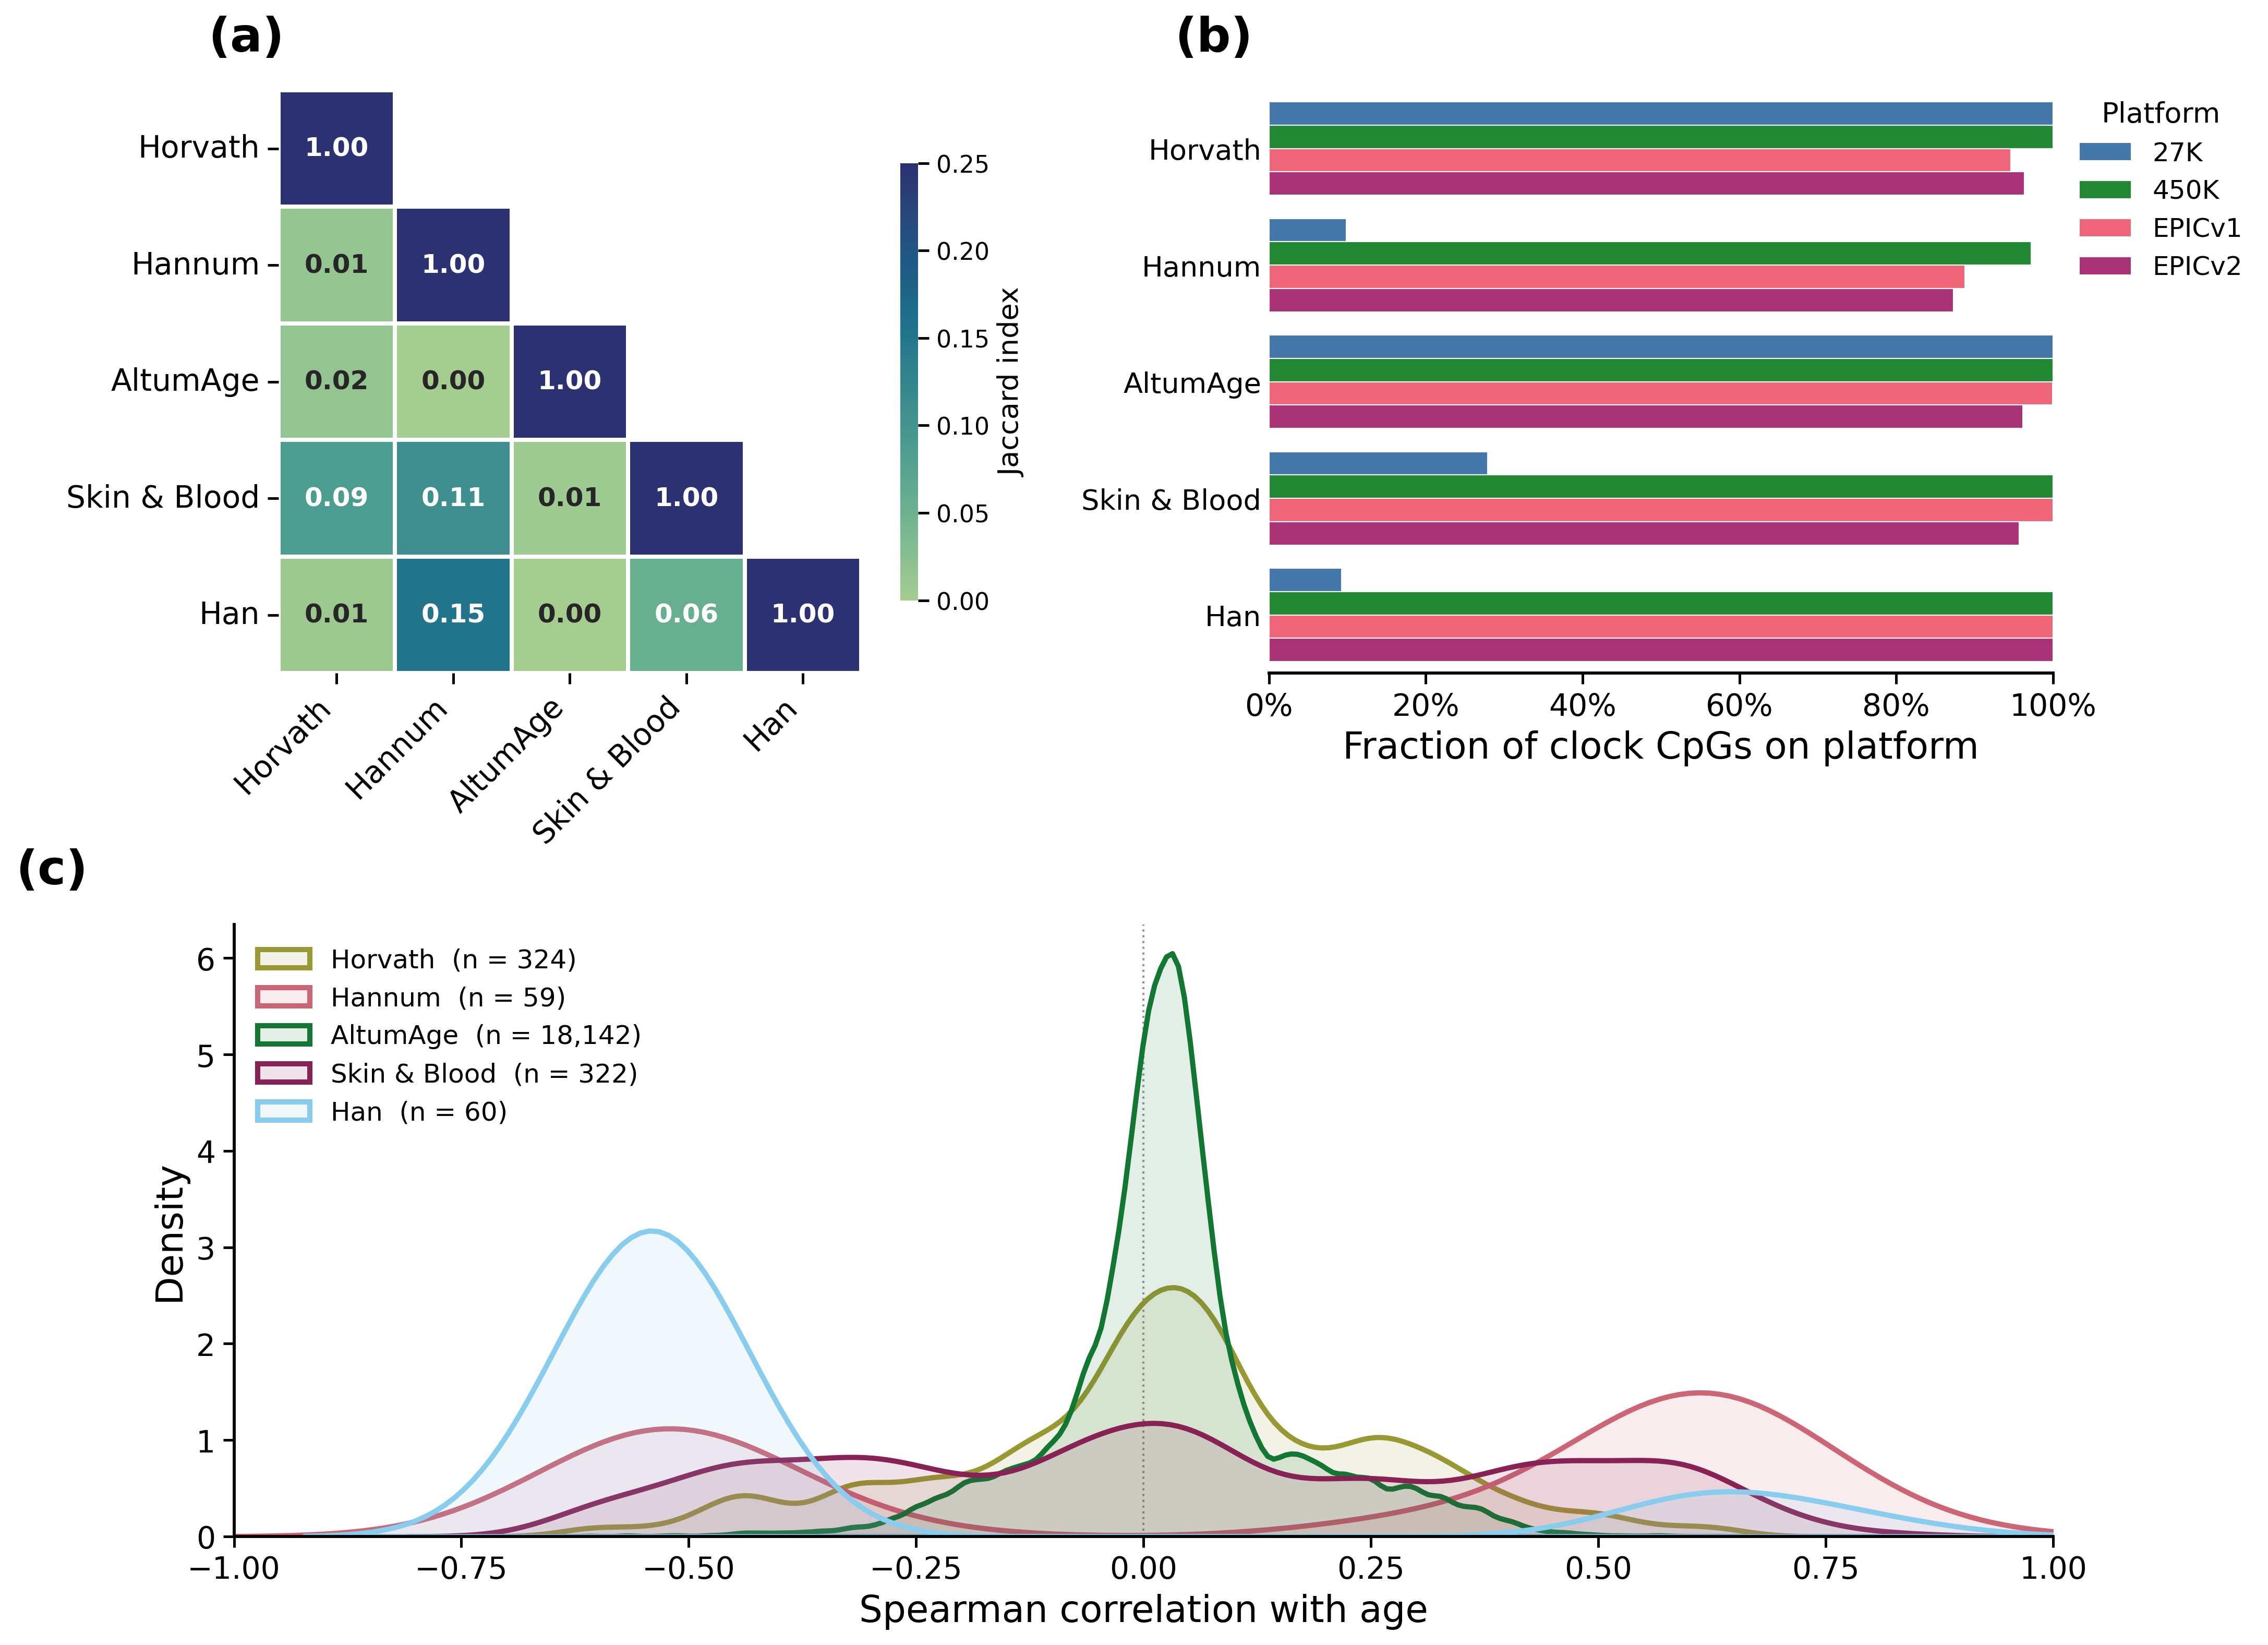

In [10]:
fig = plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.0, 1.05], hspace=0.42, wspace=0.32, figure=fig)
ax_a = fig.add_subplot(gs[0, 0]); ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

panel_jaccard(clock_cpgs, ax_a)
panel_coverage(clock_cpgs, platforms, ax_b)
panel_density_whole(df_whole, ax_c, legend=True)
for ax, L in [(ax_a, "a"), (ax_b, "b"), (ax_c, "c")]:
    ax.text(-0.12, 1.05, f"({L})", transform=ax.transAxes,
            fontsize=22, fontweight="bold", va="bottom", ha="left")

out = Path(OUT_DIR) / "composite_clock_problems"
fig.savefig(str(out)+".png", dpi=DPI); fig.savefig(str(out)+".pdf"); fig.savefig(str(out)+".svg")
print(f"  -> {out}.png / .pdf / .svg")
plt.show()


## Panel (d) — per-study small multiples (separate figure for Inkscape)

Studies ordered by sample size (largest first). Shared axes/range, sparse −1/0/1 ticks, shared row/column labels, no legend (colours match panel c).

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont:

  -> figures/panel_d_per_study.png / .pdf / .svg


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont:

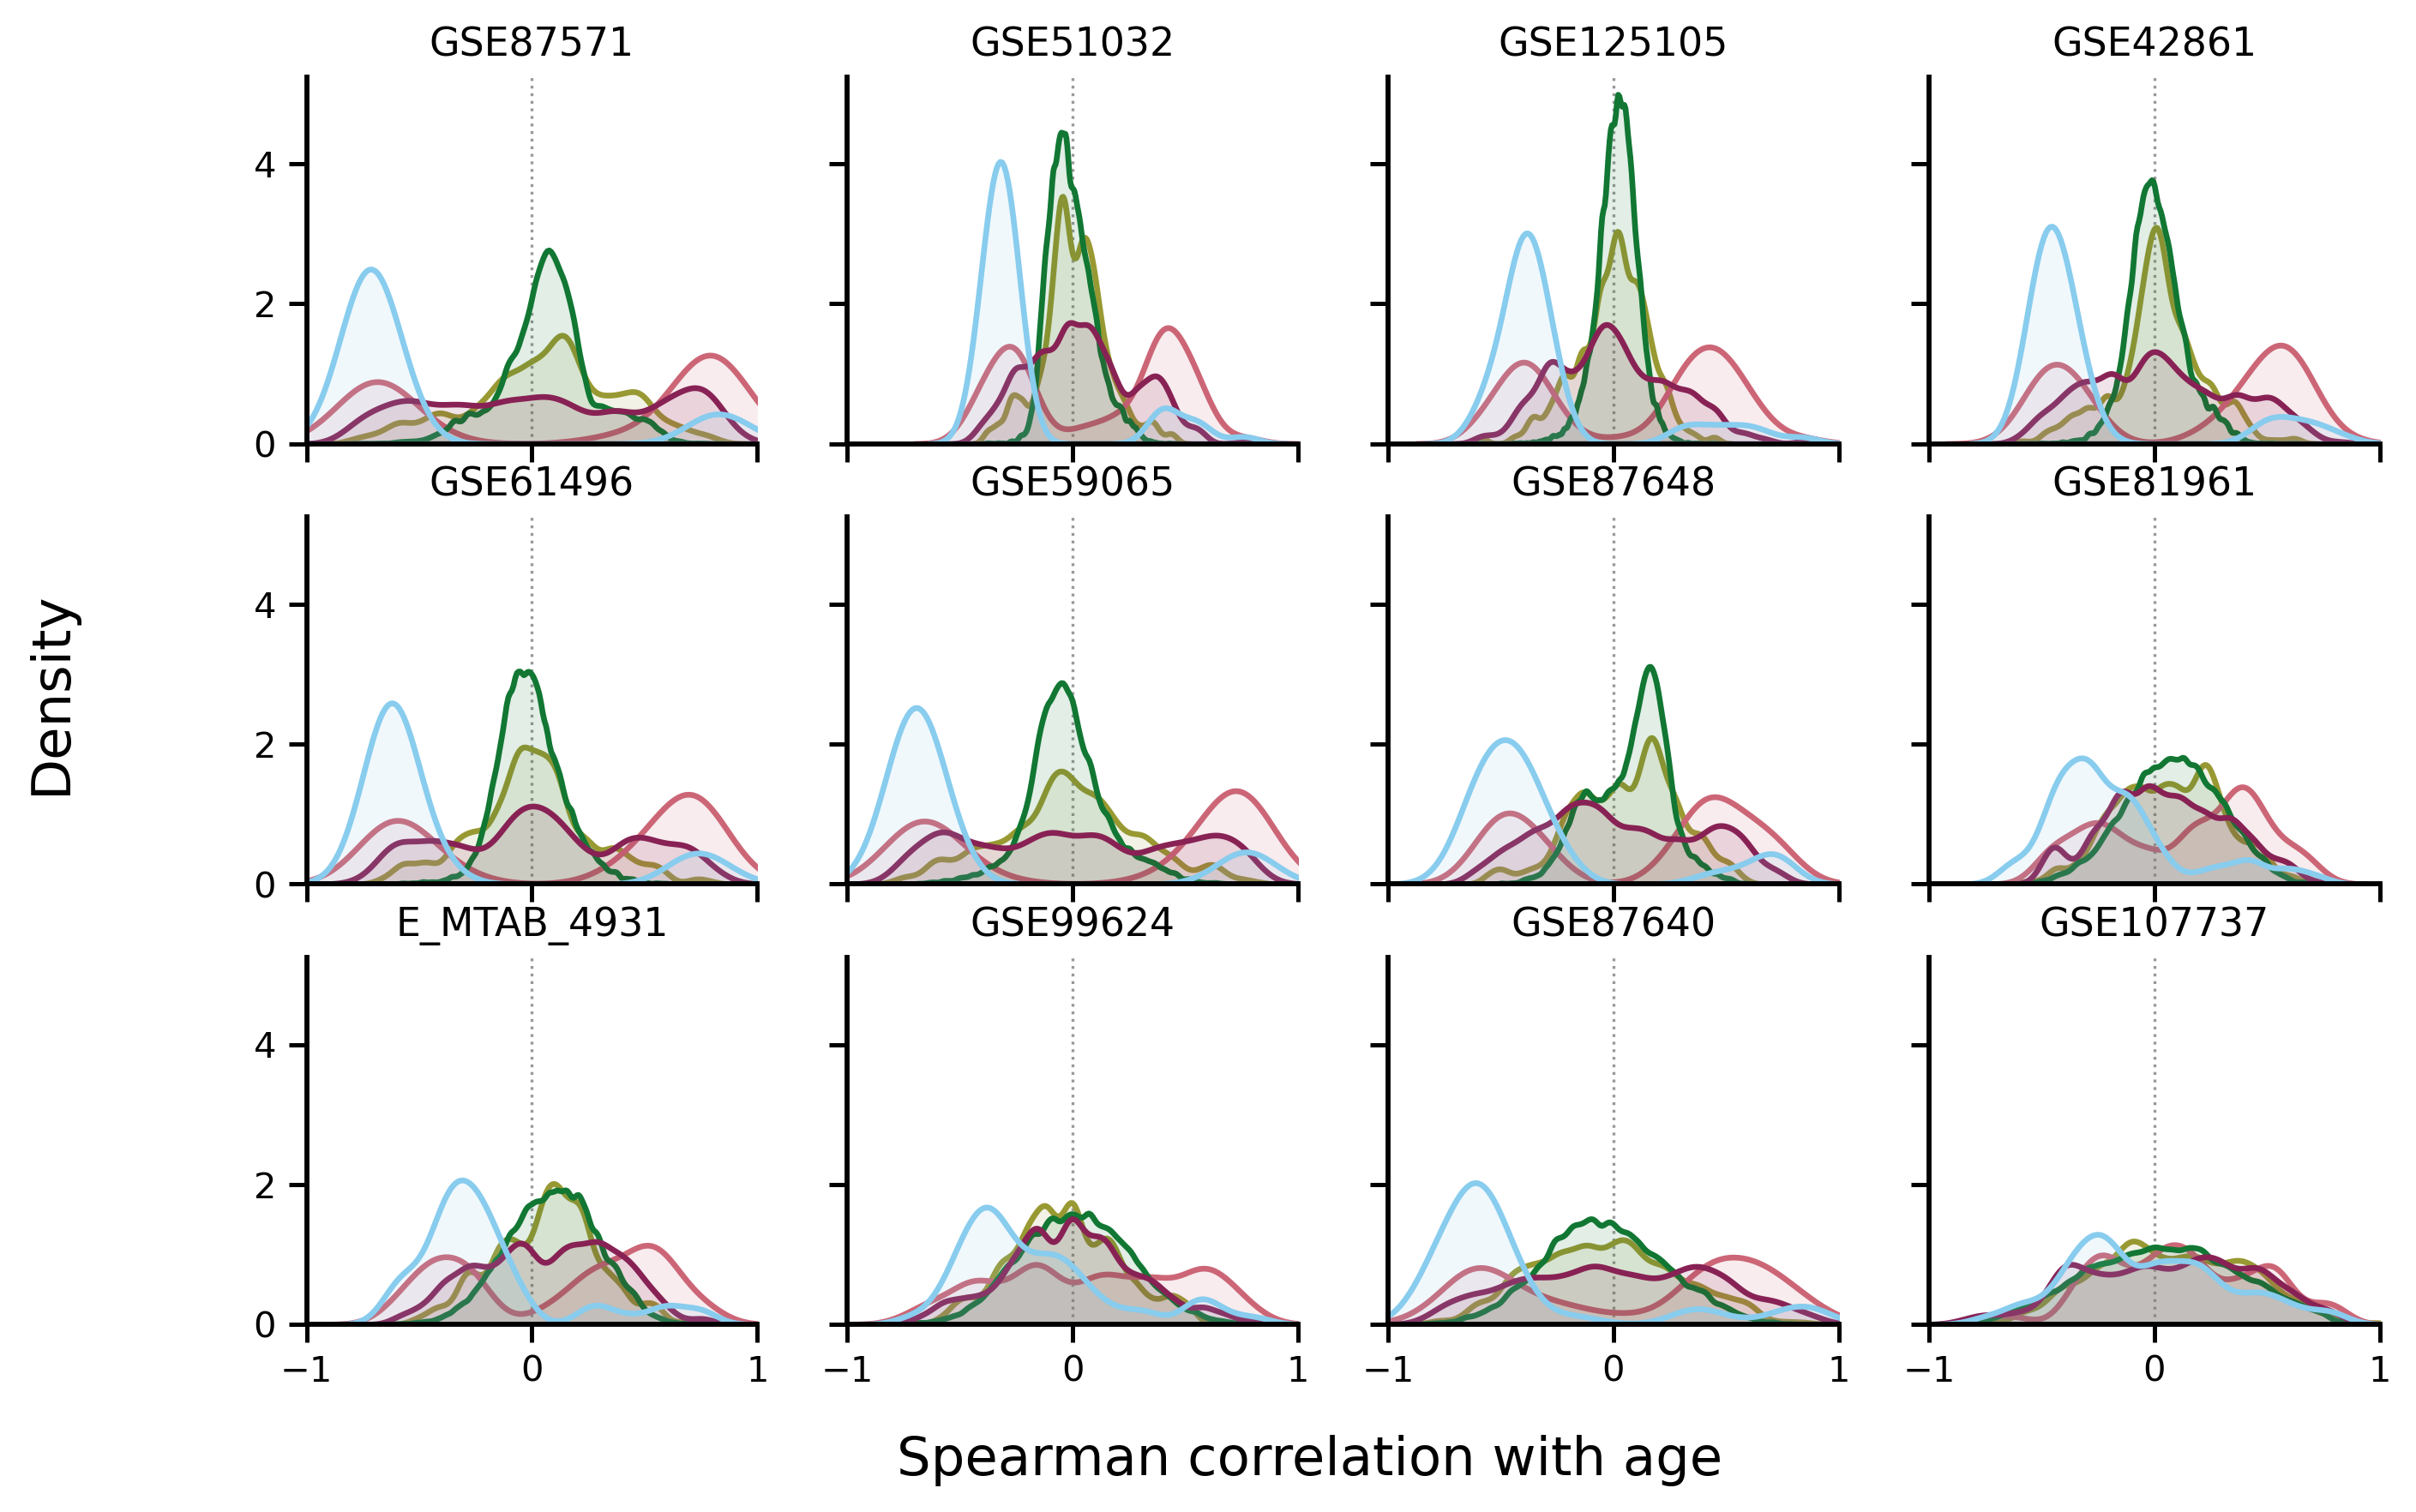

In [11]:
if df_per.empty:
    print("Panel (d) skipped — df_per is empty (PANEL_D_ENABLED was False).")
else:
    # Order studies by sample size (from the samplesheet — always available, cheap)
    _meta = pd.read_csv(METADATA_CSV)
    _counts = _meta[STUDY_COL].astype(str).value_counts()
    studies_present = [s for s in _counts.index if s in set(df_per["study"].unique())]
    studies_present += [s for s in sorted(df_per["study"].unique()) if s not in studies_present]

    fig_d, axes_d = panel_density_per_study(df_per, studies_present, ncols=4)
    out_d = Path(OUT_DIR) / "panel_d_per_study"
    fig_d.savefig(str(out_d)+".png", dpi=DPI); fig_d.savefig(str(out_d)+".pdf")
    fig_d.savefig(str(out_d)+".svg")
    print(f"  -> {out_d}.png / .pdf / .svg")
    plt.show()
